In [319]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [320]:
df=pd.read_csv('/content/drive/MyDrive/Dataset Datasci/eco-friendly-product-dataset.csv')
df.drop('Unnamed: 0',axis=1,inplace=True)

In [321]:
df

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,02-01-2022,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,09-01-2022,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,16-01-2022,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,23-01-2022,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,30-01-2022,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1
...,...,...,...,...,...,...,...,...,...
623,01-12-2024,West,31.000074,47.662804,47.235254,122.493353,1,441.100930,2024Q4
624,08-12-2024,West,35.341897,79.061813,92.526726,135.844589,0,499.099269,2024Q4
625,15-12-2024,West,30.994748,79.742460,40.328455,143.787383,0,500.565322,2024Q4
626,22-12-2024,West,40.249060,70.010242,64.437233,136.029077,0,449.505525,2024Q4


In [322]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 628 entries, 0 to 627
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   week_start          628 non-null    object 
 1   region              628 non-null    object 
 2   avg_temp            628 non-null    float64
 3   google_trend_score  628 non-null    float64
 4   marketing_spend     628 non-null    float64
 5   store_visits        628 non-null    float64
 6   holiday_flag        628 non-null    int64  
 7   sales               628 non-null    float64
 8   quarter             628 non-null    object 
dtypes: float64(5), int64(1), object(3)
memory usage: 44.3+ KB


In [323]:
df.describe()

,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales
count,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,24.986046,71.788369,50.601523,146.670486,0.181529,531.869402
std,8.120082,14.660826,21.721709,17.728933,0.385763,60.638006
min,-3.707696,20.000000,-11.654688,100.320913,0.000000,423.263286
25%,19.558428,61.802410,35.745655,133.672368,0.000000,487.488359
50%,25.770820,72.039636,51.292144,146.309609,0.000000,515.715335
75%,31.166459,81.646194,64.860207,159.443478,0.000000,579.248010
max,44.825052,100.000000,116.255308,202.855078,1.000000,702.612738


In [324]:
df.describe(include='object')

,week_start,region,quarter
count,628,628,628
unique,157,4,12
top,02-01-2022,North,2023Q4
freq,4,157,56


In [325]:
df.isnull().sum()

,0
week_start,0
region,0
avg_temp,0
google_trend_score,0
marketing_spend,0
store_visits,0
holiday_flag,0
sales,0
quarter,0


In [326]:
df.duplicated().sum()

np.int64(0)

In [327]:
df.shape

(628, 9)

In [328]:
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter
0,02-01-2022,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,2022Q1
1,09-01-2022,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,2022Q1
2,16-01-2022,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,2022Q1
3,23-01-2022,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,2022Q1
4,30-01-2022,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,2022Q1


In [329]:
import datetime as dt

df['week_start']=pd.to_datetime(df['week_start'],dayfirst=True)

In [330]:
df['week_start'].dtypes

dtype('<M8[ns]')

In [331]:
df['week_start'].isnull().sum()

np.int64(0)

In [332]:
df['quarter']="Q" + (df['week_start'].dt.quarter.astype(str))

In [333]:
df['quarter']

,quarter
0,Q1
1,Q1
2,Q1
3,Q1
4,Q1
...,...
623,Q4
624,Q4
625,Q4
626,Q4


In [334]:
df['year']=df['week_start'].dt.year

In [335]:
df['year'].head()

,year
0,2022
1,2022
2,2022
3,2022
4,2022


In [336]:
df['Day']=df['week_start'].dt.day
df['Day']

,Day
0,2
1,9
2,16
3,23
4,30
...,...
623,1
624,8
625,15
626,22


In [337]:
df.head()

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,Day
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,2
1,2022-01-09,North,13.498203,56.721545,42.961597,129.713810,0,478.079702,Q1,2022,9
2,2022-01-16,North,20.155553,63.583106,41.756808,138.380782,1,506.284918,Q1,2022,16
3,2022-01-23,North,18.852930,47.855055,83.285668,140.217833,1,512.270721,Q1,2022,23
4,2022-01-30,North,16.324140,98.691569,14.112839,168.959707,0,517.403233,Q1,2022,30


EDA

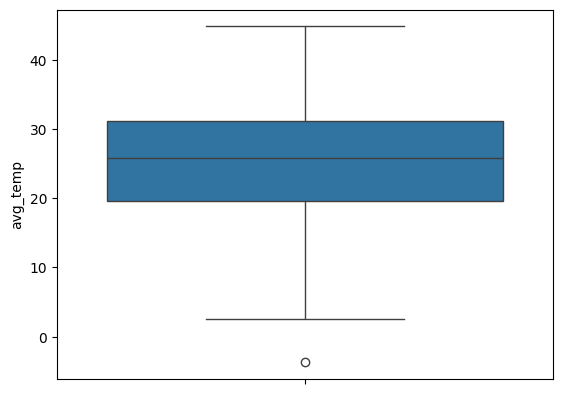

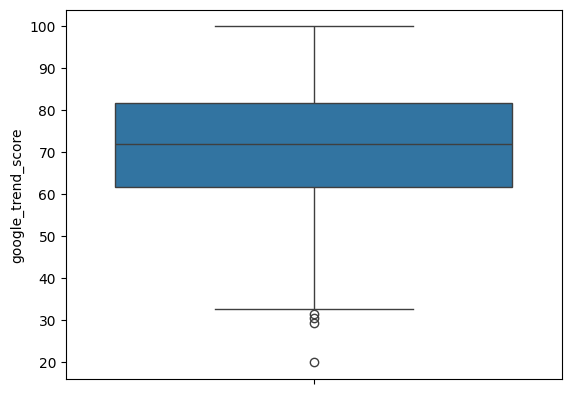

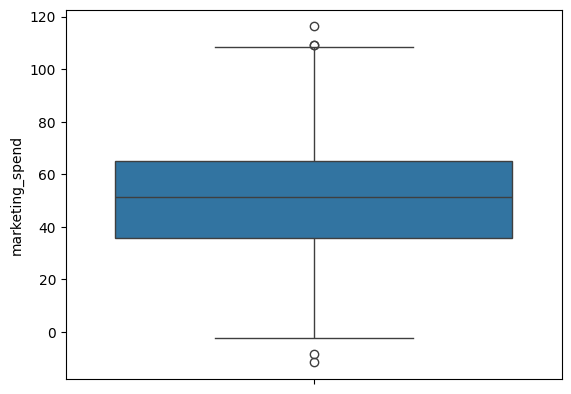

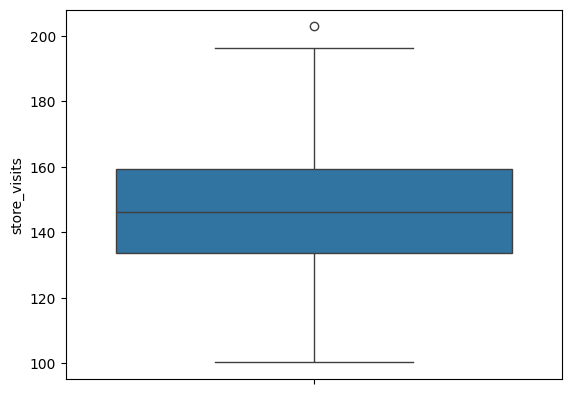

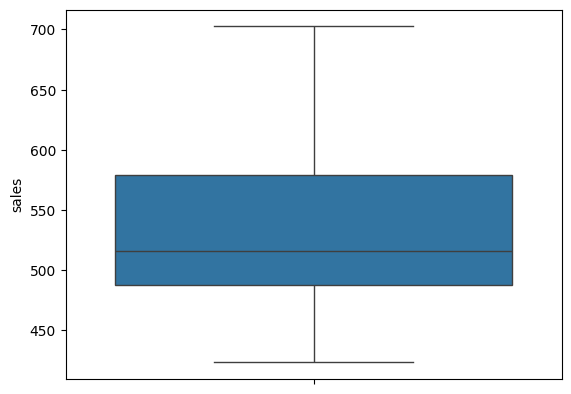

In [338]:
numeric_col = df.select_dtypes(include=float).columns
numeric_col
for col in numeric_col:
  sns.boxplot(df[col])
  plt.show()

In [339]:
for i in numeric_col:
  q1 = df[i].quantile(0.25)
  q3 = df[i].quantile(0.75)

  iqr = q3 - q1

  lower = q1 - (iqr * 1.5)
  upper = q3 + (iqr * 1.5)

  df  = df[(df[i] > lower) & (df[i] < upper)]

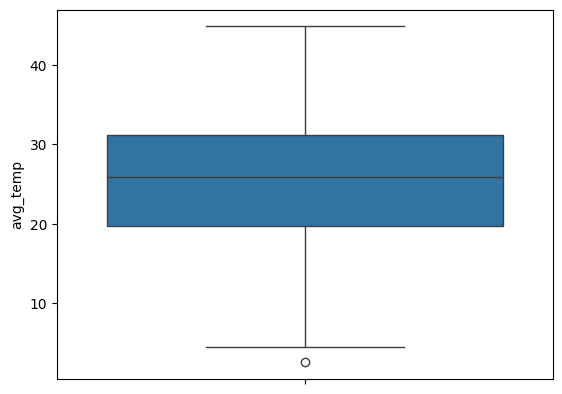

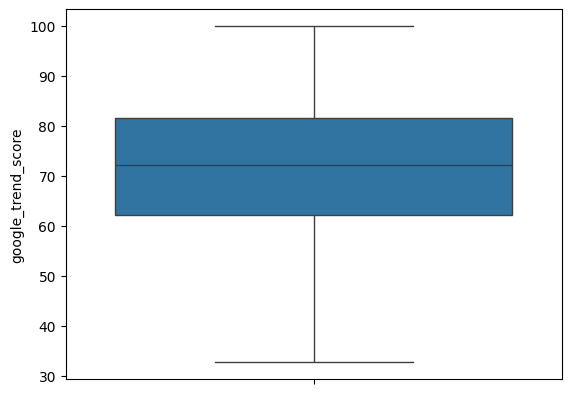

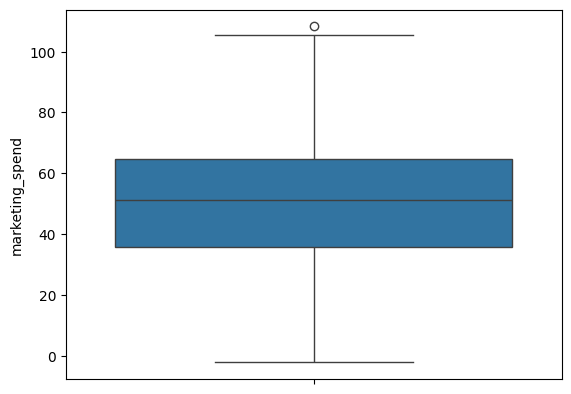

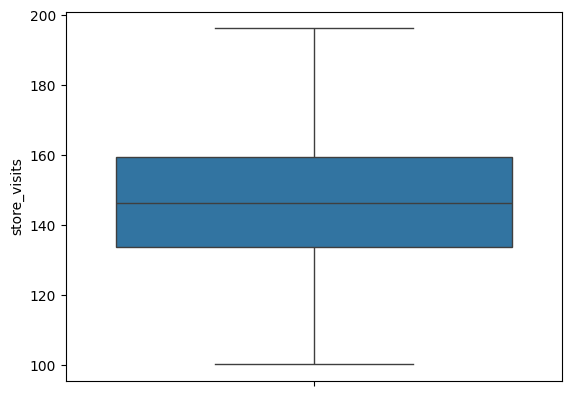

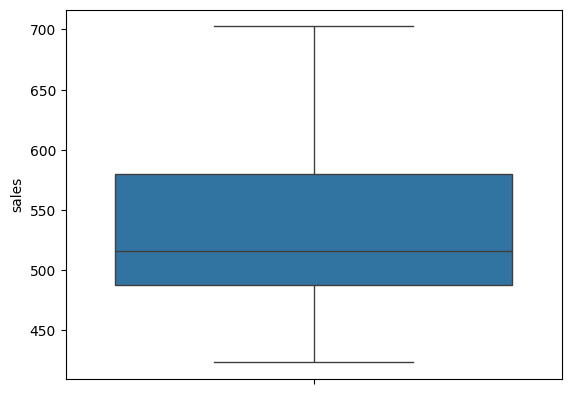

In [340]:
for col in numeric_col:
  sns.boxplot(df[col])
  plt.show()

In [341]:
t=df.groupby('year')['sales'].sum().reset_index()
fig = px.bar(t, x='year', y='sales', title='Total Sales by Year',text_auto=True)
fig.update_xaxes(dtick=1)
fig.show()



In [342]:
t=df.groupby('region')['sales'].sum().reset_index()

fig = px.pie(t,t['region'],values=t['sales'],title="Region Sales Contribution % ")
fig.show()

In [343]:
df['month_name']=df['week_start'].dt.month_name()
df['month_name'].head()

,month_name
0,January
1,January
2,January
3,January
4,January


In [344]:
df['month_number']=df['week_start'].dt.month

In [345]:
t=df.groupby(['year','month_name','month_number'])['sales'].sum().reset_index().sort_values(by=['year','month_number'])
t['year'] = t['year'].astype(str)

fig = px.line(t, x='month_name', y='sales', color='year', title='Monthly Sales Comparison Over Years',markers=True)
fig.show()

In [346]:
t=df.groupby('quarter')['sales'].sum().reset_index()
fig = px.bar(t, x='quarter', y='sales', title='Total Sales by Quarter',text_auto=True,color='quarter')
fig.show()



In [347]:
t=df.groupby(['month_number','month_name'])['sales'].sum().reset_index().sort_values(by='month_number')
fig = px.bar(t, x='month_name', y='sales', title='Total Sales by Month',text_auto=True,color='month_name')
fig.show()



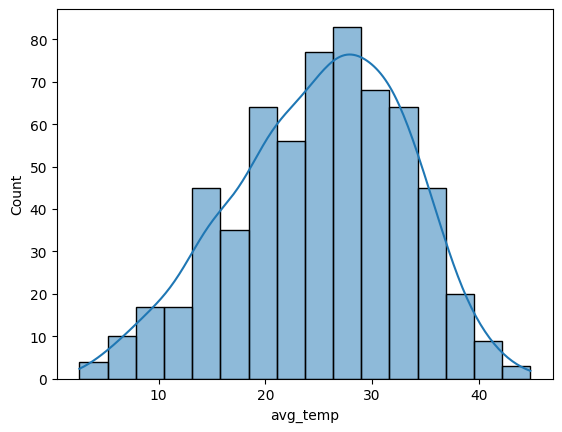

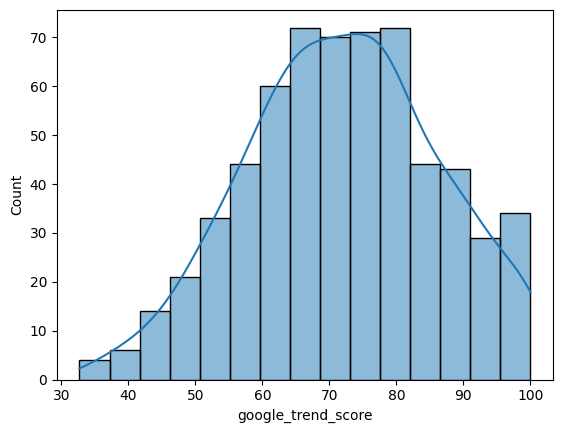

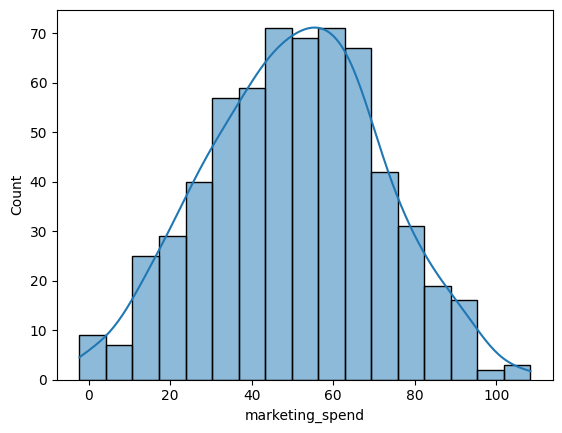

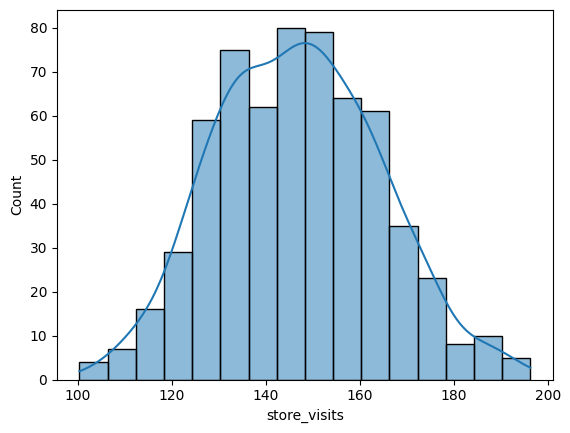

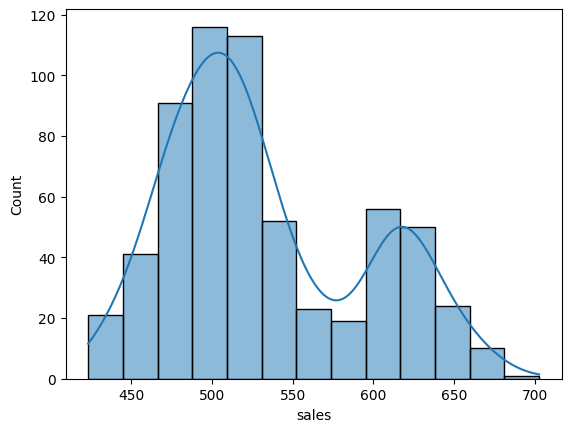

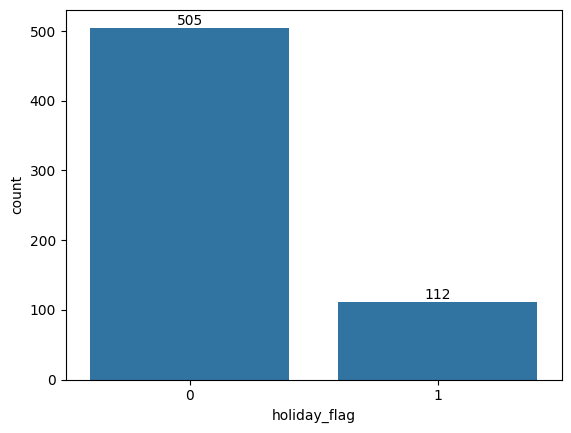

In [348]:
for i in numeric_col:
  sns.histplot(data=df,x=df[i],kde=True)
  plt.show()

t=df['holiday_flag'].value_counts().reset_index()
ax=sns.barplot(t,x='holiday_flag',y='count')
ax.bar_label(ax.containers[0])
plt.show()

<Axes: >

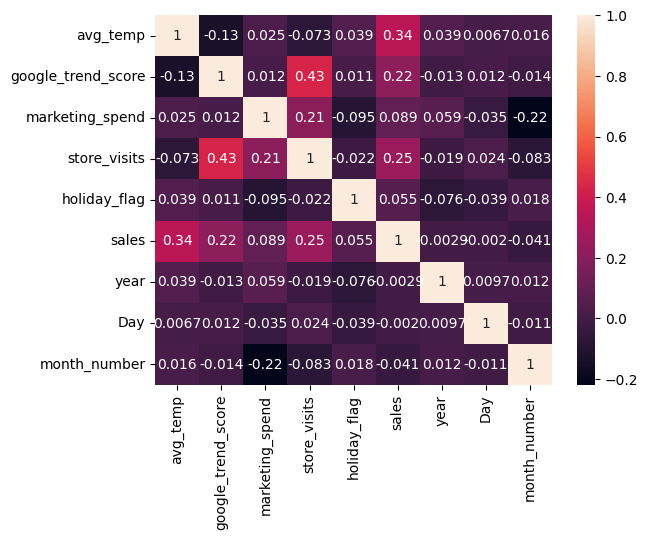

In [349]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

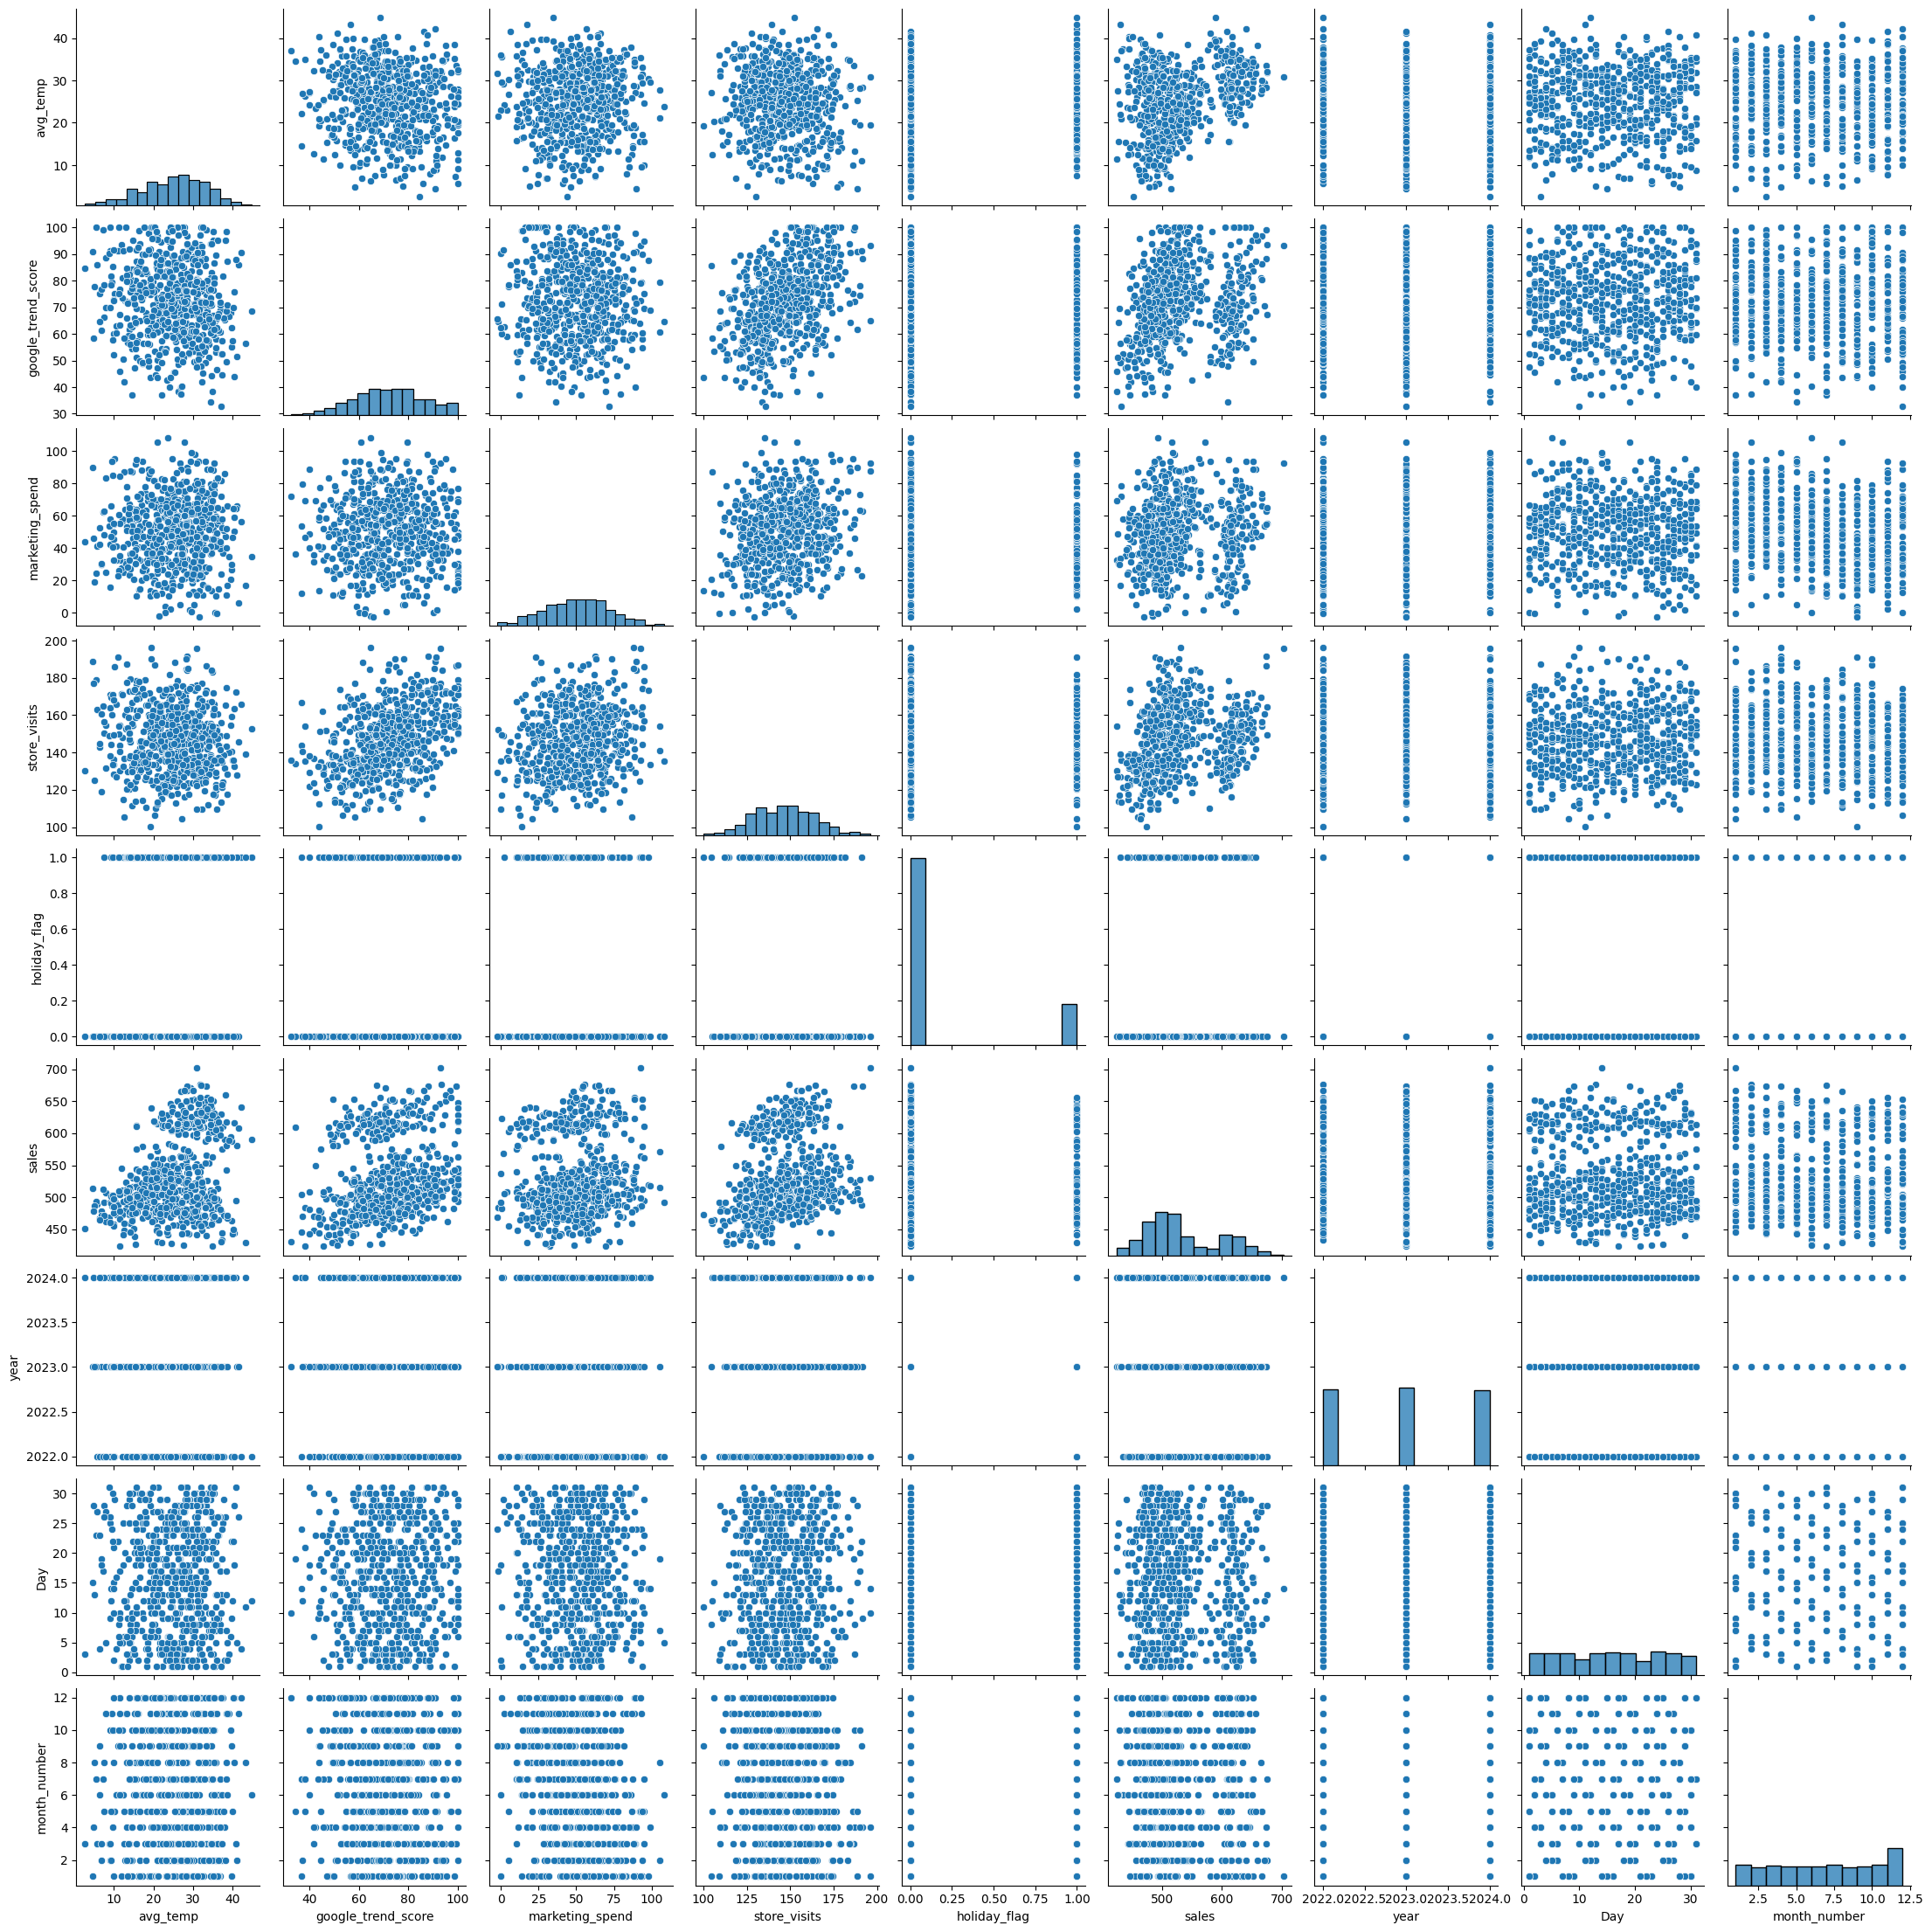

In [350]:
sns.pairplot(df)
plt.show()

In [351]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617 entries, 0 to 627
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   week_start          617 non-null    datetime64[ns]
 1   region              617 non-null    object        
 2   avg_temp            617 non-null    float64       
 3   google_trend_score  617 non-null    float64       
 4   marketing_spend     617 non-null    float64       
 5   store_visits        617 non-null    float64       
 6   holiday_flag        617 non-null    int64         
 7   sales               617 non-null    float64       
 8   quarter             617 non-null    object        
 9   year                617 non-null    int32         
 10  Day                 617 non-null    int32         
 11  month_name          617 non-null    object        
 12  month_number        617 non-null    int32         
dtypes: datetime64[ns](1), float64(5), int32(3), int64(1), o

In [352]:
cat_col=df.select_dtypes(include='object').columns

In [353]:
numeric_col

Index(['avg_temp', 'google_trend_score', 'marketing_spend', 'store_visits',
       'sales'],
      dtype='object')

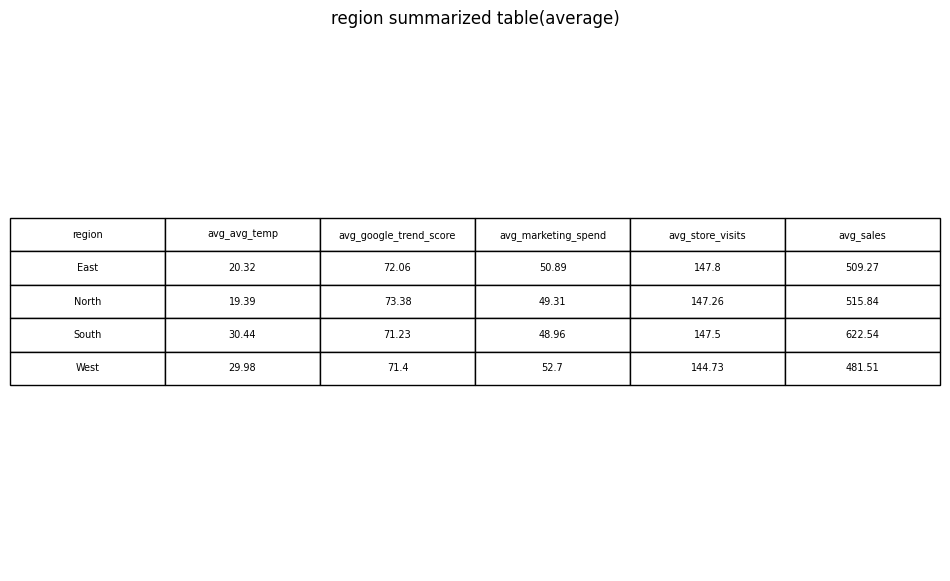

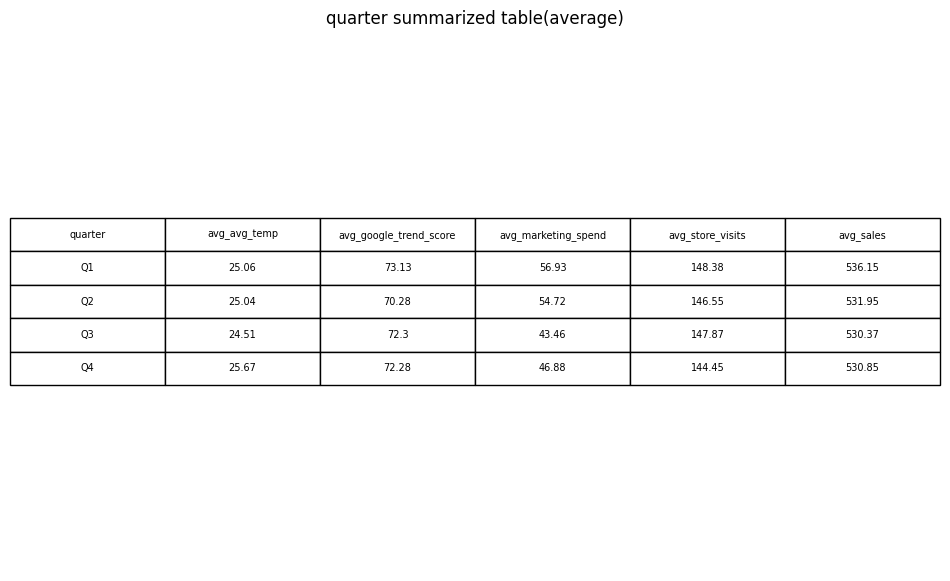

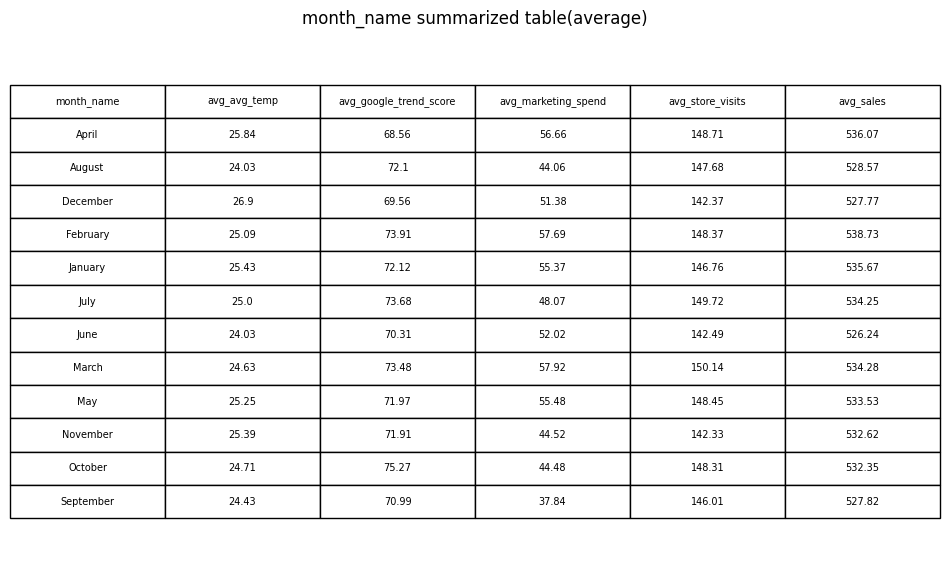

In [354]:
from pandas.plotting import table
for i in cat_col:
    t=df.groupby(i).agg({'avg_temp':'mean','google_trend_score':'mean', 'marketing_spend':'mean', 'store_visits':'mean',
       'sales':'mean'}).round(2).add_prefix('avg_').reset_index()


    fig, ax = plt.subplots(figsize=(12, 7))
    ax.axis('off')
    table = ax.table(cellText=t.values, colLabels=t.columns, loc='center', cellLoc='center')
    table.scale(1,2)
    plt.title(f"{i} summarized table(average)")
    plt.show()

In [355]:
data=df.sort_values('week_start').reset_index()

In [356]:
data.drop('index',axis='columns',inplace=True)

In [357]:
data

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,Day,month_name,month_number
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,2,January,1
1,2022-01-02,West,23.211046,86.776865,60.986313,165.962842,0,523.292535,Q1,2022,2,January,1
2,2022-01-02,South,26.852417,67.493229,52.934274,162.431104,0,616.393634,Q1,2022,2,January,1
3,2022-01-02,East,36.075102,62.400842,-0.348662,109.381586,0,492.721598,Q1,2022,2,January,1
4,2022-01-09,West,39.770787,62.413799,30.027215,159.437294,1,463.366184,Q1,2022,9,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,2024-12-22,South,32.121171,72.150088,78.376213,160.917441,0,632.988400,Q4,2024,22,December,12
613,2024-12-29,South,30.973037,58.862941,23.599550,124.974844,0,600.182976,Q4,2024,29,December,12
614,2024-12-29,North,18.136337,65.970459,26.622075,127.171929,1,500.525044,Q4,2024,29,December,12
615,2024-12-29,East,17.799158,84.374326,77.799107,135.140906,0,476.049973,Q4,2024,29,December,12


**Regression Model:**

In [358]:
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error ,mean_absolute_error ,root_mean_squared_error ,r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [359]:
data.corr(numeric_only=True)['sales']

,sales
avg_temp,0.341285
google_trend_score,0.215035
marketing_spend,0.089264
store_visits,0.252136
holiday_flag,0.054546
sales,1.000000
year,-0.002876
Day,-0.001958
month_number,-0.040515


In [360]:
x=data.drop(columns=['week_start','sales','month_name'],axis=1).replace({"Q1":1,"Q2":2,'Q3':3,'Q4':4})
print(x.head())

  region   avg_temp  google_trend_score  marketing_spend  store_visits  \
0  North  16.148359           77.731496        59.477217    171.287943   
1   West  23.211046           86.776865        60.986313    165.962842   
2  South  26.852417           67.493229        52.934274    162.431104   
3   East  36.075102           62.400842        -0.348662    109.381586   
4   West  39.770787           62.413799        30.027215    159.437294   

   holiday_flag  quarter  year  Day  month_number  
0             0        1  2022    2             1  
1             0        1  2022    2             1  
2             0        1  2022    2             1  
3             0        1  2022    2             1  
4             1        1  2022    9             1  


/tmp/ipykernel_35455/1840258046.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [361]:
y=data['sales']

In [362]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   region              617 non-null    object 
 1   avg_temp            617 non-null    float64
 2   google_trend_score  617 non-null    float64
 3   marketing_spend     617 non-null    float64
 4   store_visits        617 non-null    float64
 5   holiday_flag        617 non-null    int64  
 6   quarter             617 non-null    int64  
 7   year                617 non-null    int32  
 8   Day                 617 non-null    int32  
 9   month_number        617 non-null    int32  
dtypes: float64(4), int32(3), int64(2), object(1)
memory usage: 41.1+ KB


In [363]:
# without normalization , onehotencoding and train_test_split
#just raw model

le=LabelEncoder()
x['region']=le.fit_transform(x['region'])
print(x.head(9))
print(y.head(9))

model=LinearRegression()
ypre=model.fit(x,y).predict(x)

print("R2_Score:",r2_score(y,ypre))

   region   avg_temp  google_trend_score  marketing_spend  store_visits  \
0       1  16.148359           77.731496        59.477217    171.287943   
1       3  23.211046           86.776865        60.986313    165.962842   
2       2  26.852417           67.493229        52.934274    162.431104   
3       0  36.075102           62.400842        -0.348662    109.381586   
4       3  39.770787           62.413799        30.027215    159.437294   
5       1  13.498203           56.721545        42.961597    129.713810   
6       0  36.546025           74.468816        56.980015    143.982180   
7       2  32.091263           76.006180        46.691094    147.392530   
8       0  16.553543           49.856434        40.777601    145.889433   

   holiday_flag  quarter  year  Day  month_number  
0             0        1  2022    2             1  
1             0        1  2022    2             1  
2             0        1  2022    2             1  
3             0        1  2022    2      

# **With Proper Scaling and OneHotEncoding**

In [364]:
x=data.drop(columns=['week_start','sales','month_name'],axis=1).replace({"Q1":1,"Q2":2,'Q3':3,'Q4':4})
print(x.head())

  region   avg_temp  google_trend_score  marketing_spend  store_visits  \
0  North  16.148359           77.731496        59.477217    171.287943   
1   West  23.211046           86.776865        60.986313    165.962842   
2  South  26.852417           67.493229        52.934274    162.431104   
3   East  36.075102           62.400842        -0.348662    109.381586   
4   West  39.770787           62.413799        30.027215    159.437294   

   holiday_flag  quarter  year  Day  month_number  
0             0        1  2022    2             1  
1             0        1  2022    2             1  
2             0        1  2022    2             1  
3             0        1  2022    2             1  
4             1        1  2022    9             1  


/tmp/ipykernel_35455/1840258046.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [365]:
cat_x_col=x.select_dtypes(include='object').columns

In [366]:
cat_x_col

Index(['region'], dtype='object')

In [367]:
num_x_col=x.select_dtypes(include='float').columns

In [368]:
num_x_col

Index(['avg_temp', 'google_trend_score', 'marketing_spend', 'store_visits'], dtype='object')

In [369]:
preprocessor=ColumnTransformer(transformers=[
    ('encoder',OneHotEncoder(),cat_x_col),
    ('scaling',StandardScaler(),num_x_col)
],
                               remainder='passthrough')

Processed_DataFrame=pd.DataFrame(preprocessor.fit_transform(x),columns=preprocessor.get_feature_names_out())
Processed_DataFrame

,encoder__region_East,encoder__region_North,encoder__region_South,encoder__region_West,scaling__avg_temp,scaling__google_trend_score,scaling__marketing_spend,scaling__store_visits,remainder__holiday_flag,remainder__quarter,remainder__year,remainder__Day,remainder__month_number
0,0.0,1.0,0.0,0.0,-1.118423,0.400216,0.426316,1.401986,0.0,1.0,2022.0,2.0,1.0
1,0.0,0.0,0.0,1.0,-0.233298,1.033248,0.497740,1.096946,0.0,1.0,2022.0,2.0,1.0
2,0.0,0.0,1.0,0.0,0.223054,-0.316300,0.116644,0.894636,0.0,1.0,2022.0,2.0,1.0
3,1.0,0.0,0.0,0.0,1.378880,-0.672686,-2.405189,-2.144224,0.0,1.0,2022.0,2.0,1.0
4,0.0,0.0,0.0,1.0,1.842039,-0.671779,-0.967526,0.723140,1.0,1.0,2022.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,0.0,0.0,1.0,0.0,0.883357,0.009606,1.320788,0.807928,0.0,4.0,2024.0,22.0,12.0
613,0.0,0.0,1.0,0.0,0.739468,-0.920283,-1.271741,-1.250989,0.0,4.0,2024.0,29.0,12.0
614,0.0,1.0,0.0,0.0,-0.869282,-0.422870,-1.128688,-1.125132,1.0,4.0,2024.0,29.0,12.0
615,1.0,0.0,0.0,0.0,-0.911538,0.865108,1.293474,-0.668641,0.0,4.0,2024.0,29.0,12.0


In [370]:
pipe=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ('Model',LinearRegression())
    ])

ypred=pipe.fit(x,y).predict(x)
print(pipe.score(x,y))

0.9094889928797013


In [371]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)


In [372]:
def metric_score(y_actual,y_predict):
  print("MSE : ",mean_squared_error(y_actual,y_predict))
  print("MAE : ",mean_absolute_error(y_actual,y_predict))
  print("RMSE : ",root_mean_squared_error(y_actual,y_predict))
  print("R2 : ",r2_score(y_actual,y_predict))




In [373]:
models = {
    'LinearRegression' : LinearRegression(),
    'Lasso':Lasso(),
    'Ridge':Ridge(),
    'ElasticNet':ElasticNet(),
    'KNeighborsRegressor':KNeighborsRegressor()
}

for name,model in models.items():
  pipe=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ('Model',model)
    ])

  pipe.fit(xtrain,ytrain)
  ypred=pipe.predict(xtest)

  print("--------------------------------------------------------------------")
  print(f"{name}")
  metric_score(ytest,ypred)
  print("--------------------------------------------------------------------")

--------------------------------------------------------------------
LinearRegression
MSE :  317.2994861285824
MAE :  13.868527390994506
RMSE :  17.812902237664204
R2 :  0.9260489571020979
--------------------------------------------------------------------
--------------------------------------------------------------------
Lasso
MSE :  353.8200332944967
MAE :  15.008387637240979
RMSE :  18.81010455299217
R2 :  0.9175373374235619
--------------------------------------------------------------------
--------------------------------------------------------------------
Ridge
MSE :  318.0477332722839
MAE :  13.903618155247996
RMSE :  17.83389282440275
R2 :  0.9258745677348246
--------------------------------------------------------------------
--------------------------------------------------------------------
ElasticNet
MSE :  1824.7863167408611
MAE :  35.077609007164476
RMSE :  42.71751767999706
R2 :  0.5747082580079463
-------------------------------------------------------------------

In [374]:
# result_acc=[]
# for i in range(10):
#   pipe=Pipeline(steps=[
#     ("preprocessing",preprocessor),
#     ('Model',PolynomialFeatures(degree=i)),
#     ("model", LinearRegression())
#     ])
#   pipe.fit(xtrain,ytrain)
#   result_acc.append(pipe.score(xtest,ytest))

# result_acc


In [375]:
result_acc=[-0.0019366062432903952,
 0.92602417614469,
 0.9226984307362112,
 0.8442038797434831,
 -1.4729354057165578,
 -0.40495913376332515,
 0.5179691434714166,
 0.7007826169971014,
 0.80399444396962,
 0.8239162547257791]

(array([-2.,  0.,  2.,  4.,  6.,  8., 10.]),
 [Text(-2.0, 0, '−2'),
  Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4'),
  Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10')])

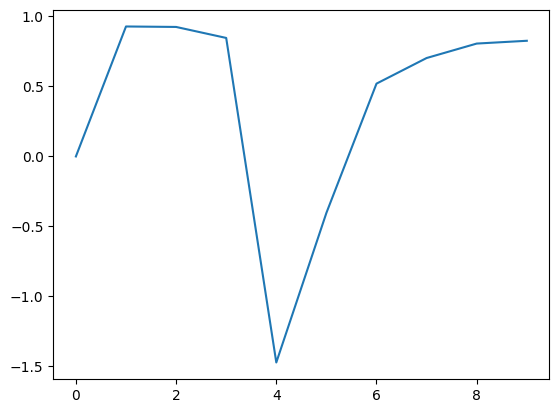

In [376]:
xaxis=[i for i in range(10)]
plt.plot(xaxis,result_acc)
plt.xticks(label=xaxis)

Best Accuracy score with hyper-parameter values :-
degree:- 1,2 and >=9

**Making Dataframe of models metric evaluation**

In [377]:
results = []

for name, model in models.items():
  pipe = Pipeline(
      steps=[('preprocessing', preprocessor), ('Model', model)]
  )

  pipe.fit(xtrain, ytrain)
  ypred = pipe.predict(xtest)


  r2 = r2_score(ytest, ypred)
  mse=mean_squared_error(ytest,ypred)
  rmse = root_mean_squared_error(ytest, ypred)
  mae = mean_absolute_error(ytest, ypred)

  results.append({'Model':name,'R2 Score':r2,'MSE':mse,'RMSE':rmse,'MAE':mae})


print(results)
print()
results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False)
results_df

[{'Model': 'LinearRegression', 'R2 Score': 0.9260489571020979, 'MSE': 317.2994861285824, 'RMSE': 17.812902237664204, 'MAE': 13.868527390994506}, {'Model': 'Lasso', 'R2 Score': 0.9175373374235619, 'MSE': 353.8200332944967, 'RMSE': 18.81010455299217, 'MAE': 15.008387637240979}, {'Model': 'Ridge', 'R2 Score': 0.9258745677348246, 'MSE': 318.0477332722839, 'RMSE': 17.83389282440275, 'MAE': 13.903618155247996}, {'Model': 'ElasticNet', 'R2 Score': 0.5747082580079463, 'MSE': 1824.7863167408611, 'RMSE': 42.71751767999706, 'MAE': 35.077609007164476}, {'Model': 'KNeighborsRegressor', 'R2 Score': 0.09024572267290587, 'MSE': 3903.4549532682204, 'RMSE': 62.47763562482355, 'MAE': 52.70165776591767}]



,Model,R2 Score,MSE,RMSE,MAE
0,LinearRegression,0.926049,317.299486,17.812902,13.868527
2,Ridge,0.925875,318.047733,17.833893,13.903618
1,Lasso,0.917537,353.820033,18.810105,15.008388
3,ElasticNet,0.574708,1824.786317,42.717518,35.077609
4,KNeighborsRegressor,0.090246,3903.454953,62.477636,52.701658


In [378]:
px.bar(data_frame=results_df,x='Model',y='R2 Score',color='Model',text_auto=True,title='Models R2_Score Evaluation')

In [379]:
px.bar(results_df,x='Model',y='RMSE',color='RMSE',title='Models Root_mean_squared_error Evaluation')

In [380]:
px.pie(results_df,names='Model',values='MAE',title='Models MAE Evaluation')

Hyperparameter Tuning for Linear Regression


In [381]:
Processed_DataFrame

,encoder__region_East,encoder__region_North,encoder__region_South,encoder__region_West,scaling__avg_temp,scaling__google_trend_score,scaling__marketing_spend,scaling__store_visits,remainder__holiday_flag,remainder__quarter,remainder__year,remainder__Day,remainder__month_number
0,0.0,1.0,0.0,0.0,-1.118423,0.400216,0.426316,1.401986,0.0,1.0,2022.0,2.0,1.0
1,0.0,0.0,0.0,1.0,-0.233298,1.033248,0.497740,1.096946,0.0,1.0,2022.0,2.0,1.0
2,0.0,0.0,1.0,0.0,0.223054,-0.316300,0.116644,0.894636,0.0,1.0,2022.0,2.0,1.0
3,1.0,0.0,0.0,0.0,1.378880,-0.672686,-2.405189,-2.144224,0.0,1.0,2022.0,2.0,1.0
4,0.0,0.0,0.0,1.0,1.842039,-0.671779,-0.967526,0.723140,1.0,1.0,2022.0,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,0.0,0.0,1.0,0.0,0.883357,0.009606,1.320788,0.807928,0.0,4.0,2024.0,22.0,12.0
613,0.0,0.0,1.0,0.0,0.739468,-0.920283,-1.271741,-1.250989,0.0,4.0,2024.0,29.0,12.0
614,0.0,1.0,0.0,0.0,-0.869282,-0.422870,-1.128688,-1.125132,1.0,4.0,2024.0,29.0,12.0
615,1.0,0.0,0.0,0.0,-0.911538,0.865108,1.293474,-0.668641,0.0,4.0,2024.0,29.0,12.0


In [382]:
xtrain,xtest,ytrain,ytest=train_test_split(Processed_DataFrame,y,test_size=0.2,random_state=42)

In [383]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV



all_linear_params = {
    "fit_intercept": [True, False],
    "positive": [True, False],
    "copy_X": [True, False]
}


lr = LinearRegression()

grid = GridSearchCV(
    estimator=lr,
    param_grid=all_linear_params,
    cv=5,
    n_jobs=-1
)

# Run search
grid.fit(xtrain, ytrain)
print(f"Optimal Parameters: {grid.best_params_}")


Optimal Parameters: {'copy_X': True, 'fit_intercept': True, 'positive': True}


## **Best Model:**

In [384]:
data

,week_start,region,avg_temp,google_trend_score,marketing_spend,store_visits,holiday_flag,sales,quarter,year,Day,month_name,month_number
0,2022-01-02,North,16.148359,77.731496,59.477217,171.287943,0,524.698094,Q1,2022,2,January,1
1,2022-01-02,West,23.211046,86.776865,60.986313,165.962842,0,523.292535,Q1,2022,2,January,1
2,2022-01-02,South,26.852417,67.493229,52.934274,162.431104,0,616.393634,Q1,2022,2,January,1
3,2022-01-02,East,36.075102,62.400842,-0.348662,109.381586,0,492.721598,Q1,2022,2,January,1
4,2022-01-09,West,39.770787,62.413799,30.027215,159.437294,1,463.366184,Q1,2022,9,January,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,2024-12-22,South,32.121171,72.150088,78.376213,160.917441,0,632.988400,Q4,2024,22,December,12
613,2024-12-29,South,30.973037,58.862941,23.599550,124.974844,0,600.182976,Q4,2024,29,December,12
614,2024-12-29,North,18.136337,65.970459,26.622075,127.171929,1,500.525044,Q4,2024,29,December,12
615,2024-12-29,East,17.799158,84.374326,77.799107,135.140906,0,476.049973,Q4,2024,29,December,12


In [385]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [386]:
LR_pipe=Pipeline(steps=[
    ("preprocessing",preprocessor),
    ('LR',LinearRegression(copy_X= True, fit_intercept= True, positive= True))
    ])

LR_pipe.fit(xtrain,ytrain)
ypred=LR_pipe.predict(xtest)


print("LinearRegression:")
metric_score(ytest,ypred)


LinearRegression:
MSE :  311.2343336879183
MAE :  13.726108728159602
RMSE :  17.64183475968184
R2 :  0.9274625249392046


In [387]:
print(LR_pipe)
print(x.columns.tolist())


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('encoder', OneHotEncoder(),
                                                  Index(['region'], dtype='object')),
                                                 ('scaling', StandardScaler(),
                                                  Index(['avg_temp', 'google_trend_score', 'marketing_spend', 'store_visits'], dtype='object'))])),
                ('LR', LinearRegression(positive=True))])
['region', 'avg_temp', 'google_trend_score', 'marketing_spend', 'store_visits', 'holiday_flag', 'quarter', 'year', 'Day', 'month_number']


In [388]:
import sklearn
print(sklearn.__version__)

1.6.1


# StreamLit Posting:

In [389]:
import joblib

# Example: Assuming 'model' is your trained machine learning model
joblib.dump(LR_pipe, 'eco_friendly_product_sales_model.pkl')

['eco_friendly_product_sales_model.pkl']

In [390]:
import sklearn
import joblib

print("sklearn:", sklearn.__version__)

model = joblib.load("eco_friendly_product_sales_model.pkl")
print(type(model))

sklearn: 1.6.1
<class 'sklearn.pipeline.Pipeline'>
